# Chapter 16 -- Proof by Example and Counterexample

> **Prerequisites:** ch001-ch015
>
> **You will learn:**
> - Why one counterexample suffices to disprove any universal claim
> - How existence proofs differ from universal proofs
> - The constructive vs non-constructive distinction
> - How to systematically search for counterexamples
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Two asymmetric proof techniques govern existence and universality:

**To prove for-all x P(x):** You cannot use examples -- you need a general argument. No finite set of examples suffices.

**To disprove for-all x P(x):** One counterexample is sufficient and definitive.

**To prove there-exists x P(x):** One example (construction) is sufficient.

**To disprove there-exists x P(x):** You need to prove for-all x NOT-P(x). A general argument is required.

This asymmetry shapes strategy: when trying to disprove, look for a counterexample. When proving existence, construct one specific object.

**Common misconception:** If a pattern holds for many cases, it is probably always true.

Euler's formula n^2+n+41 produces primes for n=0 through 39 (forty consecutive cases) then fails at n=40. No threshold of examples guarantees universal truth.

## 2. Intuition & Mental Models

**Physical analogy:** Quality testing. To prove every component is non-defective, you must test them all. To prove at least one is defective, find just one. The asymmetry of inspection burden is the same as the asymmetry of proof burden.

**Computational analogy:** Program correctness. To prove a program correct for all inputs, you need a proof or exhaustive test. To prove it has a bug, you need one failing test case. A fuzzer is a counterexample-finding machine.

Recall from ch004 *(Mathematical Curiosity and Exploration)*: test_conjecture found that Euler's formula failed at n=40. That was counterexample finding. This chapter formalizes the method.

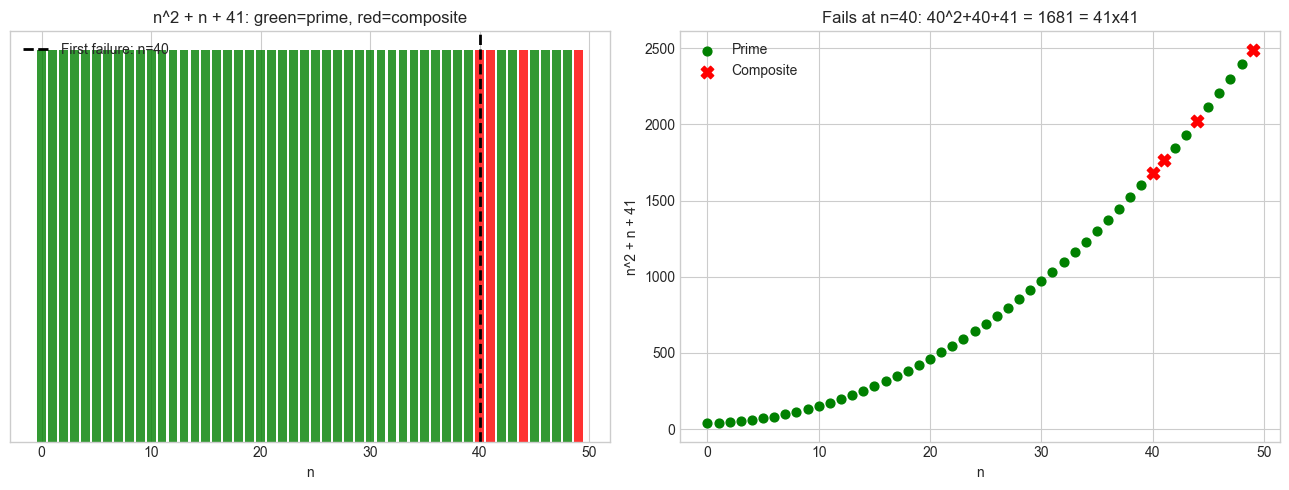

n=40: 40^2+40+41 = 1681 = 41 x 41
40 examples do not establish universal truth.


In [1]:
# --- Visualization: Euler's formula -- 40 successes then failure ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def is_prime(n):
    if n < 2: return False
    if n == 2: return True
    if n % 2 == 0: return False
    return all(n % i != 0 for i in range(3, int(n**0.5)+1, 2))

ns = np.arange(0, 50)
vals = ns**2 + ns + 41
prime_flags = [is_prime(int(v)) for v in vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['green' if p else 'red' for p in prime_flags]
axes[0].bar(ns, [1]*len(ns), color=colors, alpha=0.8)
axes[0].set_xlabel('n')
axes[0].set_title('n^2 + n + 41: green=prime, red=composite')
axes[0].set_yticks([])
ce = next(n for n in ns if not prime_flags[n])
axes[0].axvline(ce, color='black', linestyle='--', linewidth=2,
                label=f'First failure: n={ce}')
axes[0].legend()

axes[1].scatter(ns[prime_flags], vals[prime_flags], color='green', s=40, label='Prime', zorder=5)
axes[1].scatter(ns[~np.array(prime_flags)], vals[~np.array(prime_flags)],
                color='red', s=80, marker='X', label='Composite', zorder=5)
axes[1].set_xlabel('n'); axes[1].set_ylabel('n^2 + n + 41')
axes[1].set_title(f'Fails at n={ce}: {ce}^2+{ce}+41 = {ce**2+ce+41} = 41x41')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"n=40: 40^2+40+41 = {40**2+40+41} = 41 x 41")
print("40 examples do not establish universal truth.")

## 4. Mathematical Formulation

**Logical structure:**

  for-all x in D: P(x)  disproved by a single x0 in D with NOT-P(x0)

  there-exists x in D: P(x)  proved by exhibiting x0 in D with P(x0)

**Existence proofs -- two types:**
- **Constructive:** Explicitly exhibit the object. Preferred.
- **Non-constructive:** Prove something exists without identifying it. Valid but unsatisfying.

**Counterexample strategy:**
1. Test boundary cases (smallest values, edge cases)
2. Test adversarial cases (designed to fail)
3. Test cases that satisfy related but weaker conditions

In [2]:
# --- Implementation: Systematic counterexample finder ---
import numpy as np

def find_counterexample(predicate, domain, max_found=5, verbose=True):
    """Systematically search for counterexamples to predicate(x)."""
    counterexamples = []
    tested = 0
    for x in domain:
        tested += 1
        if not predicate(x):
            counterexamples.append(x)
            if verbose:
                print(f"  Counterexample #{len(counterexamples)}: x = {x}")
            if len(counterexamples) >= max_found:
                break
    if verbose:
        if counterexamples:
            print(f"  Found {len(counterexamples)} in {tested} tests.")
        else:
            print(f"  No counterexample in {tested} tests.")
    return counterexamples

def is_prime(n):
    if n < 2: return False
    if n == 2: return True
    if n % 2 == 0: return False
    return all(n % i != 0 for i in range(3, int(n**0.5)+1, 2))

print("=== Conjecture: n^2+n+41 always prime ===")
find_counterexample(lambda n: is_prime(n**2+n+41), range(0, 50))

print("\n=== Conjecture: a^2 + b^2 = c^2 has no positive integer solution (FALSE) ===")
print("  Searching for Pythagorean triples up to 20:")
for a in range(1, 20):
    for b in range(a, 20):
        c2 = a**2 + b**2
        c = int(c2**0.5)
        if c*c == c2:
            print(f"  Found: {a}^2 + {b}^2 = {c}^2 -- conjecture is FALSE.")
            break
    else: continue
    break

print("\n=== Conjecture: sum(k, k=1..n) is always even (FALSE) ===")
find_counterexample(lambda n: n*(n+1)//2 % 2 == 0, range(1, 20))

=== Conjecture: n^2+n+41 always prime ===
  Counterexample #1: x = 40
  Counterexample #2: x = 41
  Counterexample #3: x = 44
  Counterexample #4: x = 49
  Found 4 in 50 tests.

=== Conjecture: a^2 + b^2 = c^2 has no positive integer solution (FALSE) ===
  Searching for Pythagorean triples up to 20:
  Found: 3^2 + 4^2 = 5^2 -- conjecture is FALSE.

=== Conjecture: sum(k, k=1..n) is always even (FALSE) ===
  Counterexample #1: x = 1
  Counterexample #2: x = 2
  Counterexample #3: x = 5
  Counterexample #4: x = 6
  Counterexample #5: x = 9
  Found 5 in 9 tests.


[1, 2, 5, 6, 9]

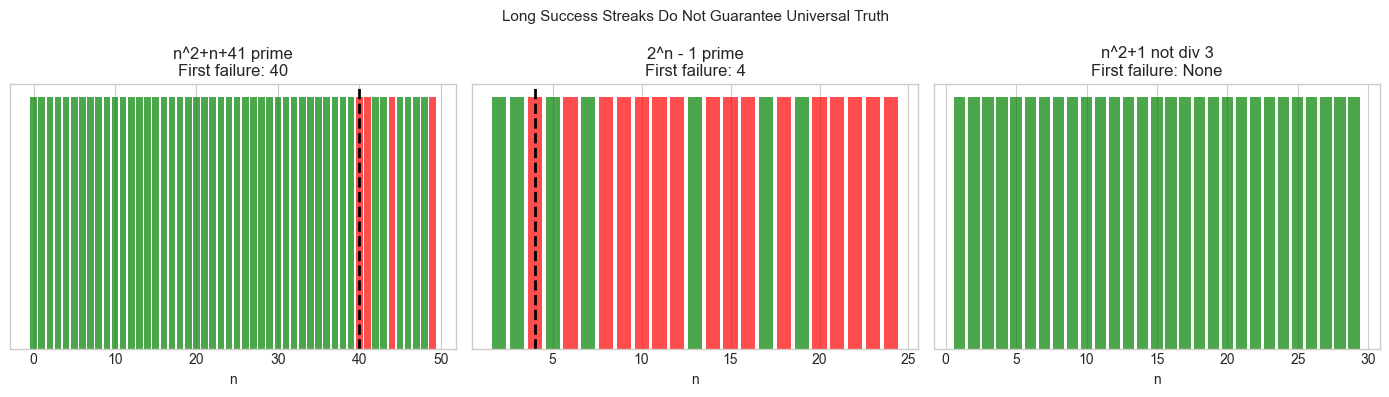

In [3]:
# --- Experiment: How long until a pattern breaks? ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def is_prime(n):
    if n < 2: return False
    if n == 2: return True
    if n % 2 == 0: return False
    return all(n % i != 0 for i in range(3, int(n**0.5)+1, 2))

late_breaking = [
    ("n^2+n+41 prime", lambda n: is_prime(n**2+n+41), list(range(0, 50))),
    ("2^n - 1 prime",  lambda n: is_prime(2**n - 1),  list(range(2, 25))),
    ("n^2+1 not div 3",lambda n: (n**2+1)%3 != 0,     list(range(1, 30))),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, pred, domain) in zip(axes, late_breaking):
    results = [(x, pred(x)) for x in domain]
    colors = ['green' if v else 'red' for _,v in results]
    first_fail = next((x for x,v in results if not v), None)
    ax.bar([r[0] for r in results], [1]*len(results), color=colors, alpha=0.7, width=0.8)
    ax.set_title(f'{name}\nFirst failure: {first_fail}')
    ax.set_yticks([]); ax.set_xlabel('n')
    if first_fail is not None:
        ax.axvline(first_fail, color='black', linestyle='--', lw=2)

plt.suptitle('Long Success Streaks Do Not Guarantee Universal Truth', fontsize=11)
plt.tight_layout(); plt.show()

## 7. Exercises

**Easy 1.** Disprove: "For all integers n, n^2 + n + 1 is odd." Find the smallest n where it is even. Hint: try n divisible by 2.

**Easy 2.** Prove by construction: there exist two irrational numbers whose sum is rational. Exhibit a specific pair and verify both are irrational.

**Medium 1.** Goldbach's conjecture: every even integer > 2 is the sum of two primes. For all even n from 4 to 1000, find at least one Goldbach decomposition n = p + q. Report the largest n that required searching the most pairs.

**Medium 2.** The intermediate value theorem guarantees: if f(a) < 0 and f(b) > 0 and f is continuous, there exists c in (a,b) with f(c)=0. Implement bisection to *constructively* find the zero of x^3 - 2x - 5 in [2, 3] to 10 decimal places.

**Hard.** Prove computationally that the sum n(n+1)/2 is divisible by 4 iff n is congruent to 0 or 3 mod 4. Verify for all n from 1 to 10000. Then generalize: for what n is n(n+1)/2 divisible by k, for k in {3, 5, 6, 8}?

In [4]:
# --- Mini Project: Counterexample database ---
def is_prime(n):
    if n < 2: return False
    if n == 2: return True
    if n % 2 == 0: return False
    return all(n % i != 0 for i in range(3, int(n**0.5)+1, 2))

conjectures = [
    {
        'name': "Euler prime formula: n^2+n+41",
        'claim': "n^2+n+41 is prime for all n >= 0",
        'first_ce': 40,
        'ce_value': f'40^2+40+41 = {40**2+40+41} = 41 * 41',
        'streak': 40,
    },
    {
        'name': "Fermat conjecture: 2^(2^n)+1 always prime",
        'claim': "All F_n = 2^(2^n)+1 are prime",
        'first_ce': 5,
        'ce_value': f'F_5 = {2**32+1} = 641 * {(2**32+1)//641}',
        'streak': 5,
    },
    {
        'name': "Sum of angles in any polygon = 180 * (n-2)",
        'claim': "True -- this actually holds (not a counterexample)",
        'first_ce': None,
        'ce_value': "Holds for all convex polygons",
        'streak': None,
    },
]

print("Famous counterexamples in mathematics:")
print("=" * 60)
for c in conjectures:
    print(f"\nConjecture: {c['name']}")
    print(f"  Claim:   {c['claim']}")
    if c['first_ce'] is not None:
        print(f"  Failed at: n = {c['first_ce']} after {c['streak']}-case streak")
        print(f"  Value:   {c['ce_value']}")
    else:
        print(f"  Status:  {c['ce_value']}")

print("\nLesson: examples build intuition. One counterexample destroys a conjecture.")

Famous counterexamples in mathematics:

Conjecture: Euler prime formula: n^2+n+41
  Claim:   n^2+n+41 is prime for all n >= 0
  Failed at: n = 40 after 40-case streak
  Value:   40^2+40+41 = 1681 = 41 * 41

Conjecture: Fermat conjecture: 2^(2^n)+1 always prime
  Claim:   All F_n = 2^(2^n)+1 are prime
  Failed at: n = 5 after 5-case streak
  Value:   F_5 = 4294967297 = 641 * 6700417

Conjecture: Sum of angles in any polygon = 180 * (n-2)
  Claim:   True -- this actually holds (not a counterexample)
  Status:  Holds for all convex polygons

Lesson: examples build intuition. One counterexample destroys a conjecture.


## 9. Chapter Summary & Connections

- Universal claims require proof for all cases; one counterexample destroys them permanently
- Existence claims require one construction; disproving them requires a universal argument
- The Euler prime formula held for 40 consecutive cases before failing; no success streak guarantees universal truth
- Constructive proofs are preferred over non-constructive ones when possible

**Forward:** Counterexample search is formalized in ch278 -- Hypothesis Testing. The existence/construction distinction reappears in ch218 -- Monte Carlo Integration.

**Backward:** This chapter complements ch015 *(Mathematical Proof Intuition)*: ch015 explains how to prove universal claims; this chapter explains how to disprove them and prove existence.